### classifier, torch

In [1]:
import torch

In [2]:
from datasets import load_dataset

ds = load_dataset('imdb', split=['train[:33%]', 'test[:33%]'])

/Users/ant.korneev/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ant.korneev/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import nltk

tokenizer = nltk.tokenize.WordPunctTokenizer()

train = [tokenizer.tokenize(text.lower()) for text in ds[0]['text']]
val = [tokenizer.tokenize(text.lower()) for text in ds[1]['text']]


In [8]:
train_labels = [label for label in ds[0]['label']]
val_labels = [label for label in ds[1]['label']]


In [9]:
PAD_TOKEN = '<pad>'

train_seq_len = 0
for t in train:
    if len(t) > train_seq_len:
        train_seq_len = len(t)

train = [text + [PAD_TOKEN] * (train_seq_len - len(text)) for text in train]

val_seq_len = 0
for t in val:
    if len(t) > val_seq_len:
        val_seq_len = len(t)

val = [text + [PAD_TOKEN] * (val_seq_len - len(text)) for text in val]

In [10]:
vocab_set = set()
for t in train:
    for w in t:
        vocab_set.add(w)
        
for t in val:
    for w in t:
        vocab_set.add(w)

In [11]:
vocab_i_map = {}
i_vocab_map = {}
for i, token in enumerate(vocab_set):
    vocab_i_map[token] = i
    i_vocab_map[i] = token

In [12]:
for i, text in enumerate(train):
    for j, token in enumerate(text):
        train[i][j] = vocab_i_map[token]
        
for i, text in enumerate(val):
    for j, token in enumerate(text):
        val[i][j] = vocab_i_map[token]

In [16]:
# [i_vocab_map[i] for i in val[1]]

In [17]:
vocab_size = len(vocab_set)
emb_dim = 64
inp_size = 512
hid_size = 1024

In [18]:
class Cls(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.embs = torch.nn.Embedding(vocab_size, emb_dim)
        
        self.lstm = torch.nn.LSTM(emb_dim, hid_size, 4)
        
        self.norm = torch.nn.LayerNorm(hid_size)
        self.dropout = torch.nn.Dropout(p=0.2)
        
        self.fc1 = torch.nn.Linear(hid_size, hid_size)
        self.activation1 = torch.nn.ReLU()
        
        self.fc2 = torch.nn.Linear(hid_size, 1)
        self.activation2 = torch.nn.Sigmoid()
        
        
        
    # X: [batch_size, seq_len]
    def forward(self, X):
        X = self.embs(X) # [batch_size, seq_len, emb_dim]
        
        X, (hn, cn) = self.lstm(X)
        
        X = self.norm(X)
        X = self.dropout(X)
        
        X = self.fc1(X) # [batch_size, seq_len, hid_size]
        X = self.activation1(X)
        
        X = self.fc2(X) # [batch_size, seq_len, 2]
        X = self.activation2(X)
    
        return X


In [19]:
dummy_batch = torch.tensor(train[:2])

In [20]:
model = Cls()

In [22]:
# model.forward(dummy_batch)

In [24]:
opt = torch.optim.Adam(model.parameters())

In [40]:
%pip install --upgrade tqdm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [45]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/var/folders/7l/3qdkg7n17mj7g3w_q8yf5xzc0000gq/T/ipykernel_3155/1375887972.py:35: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()
 31%|███▏      | 161/515 [16:50<37:01,  6.27s/it]


KeyboardInterrupt: 

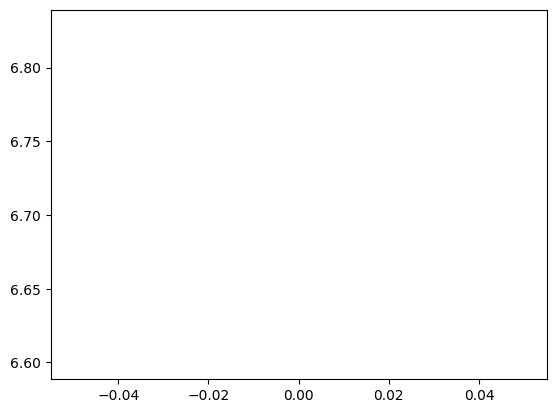

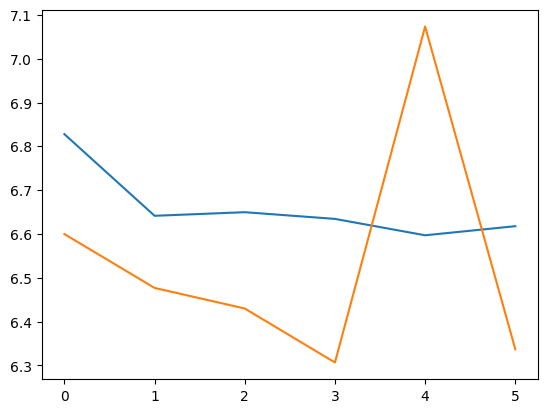

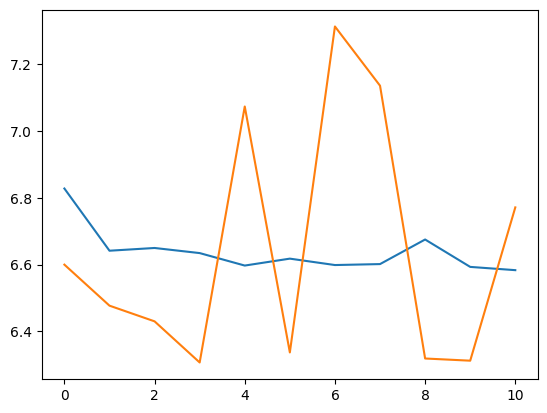

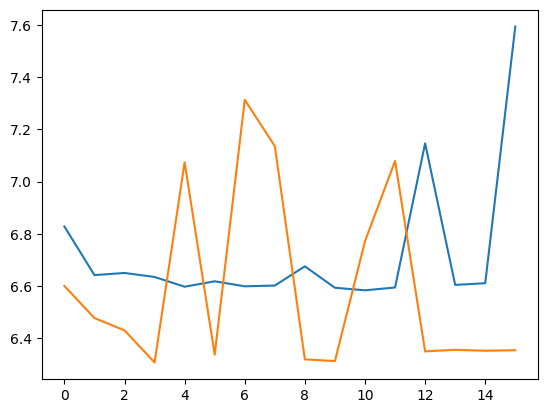

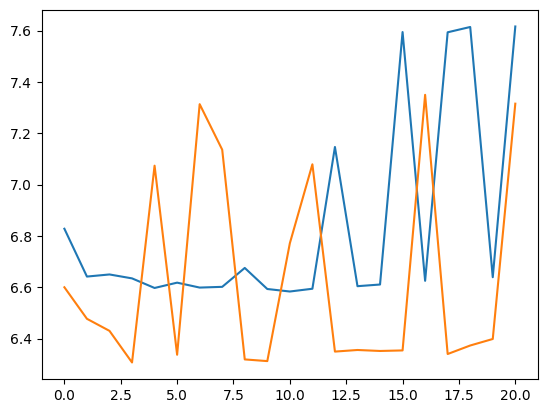

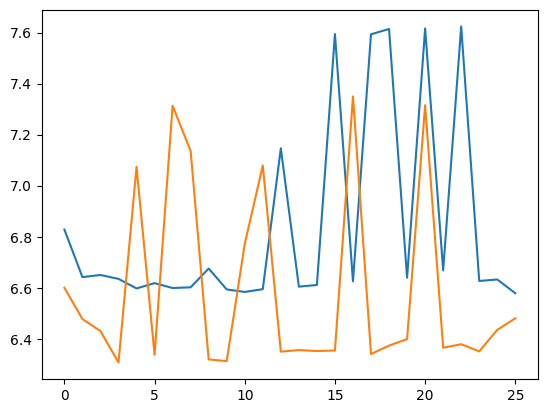

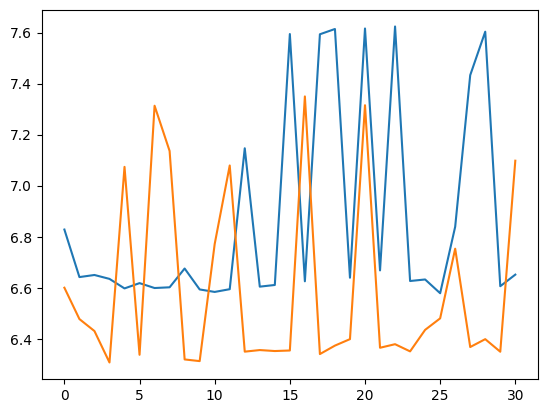

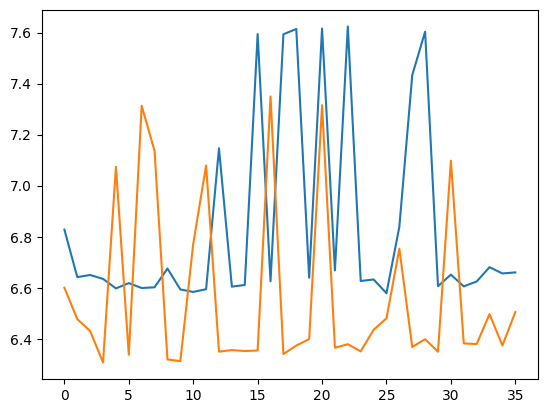

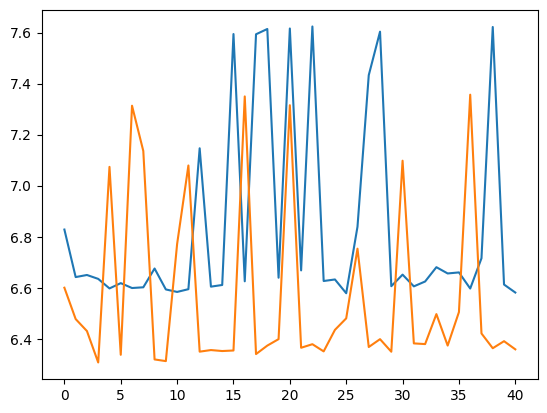

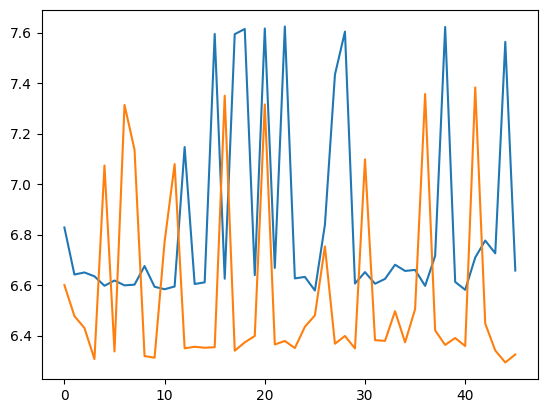

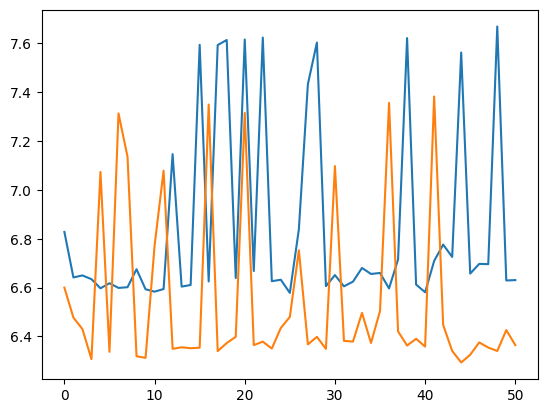

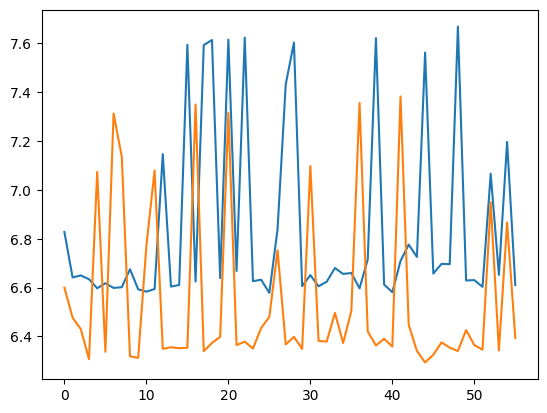

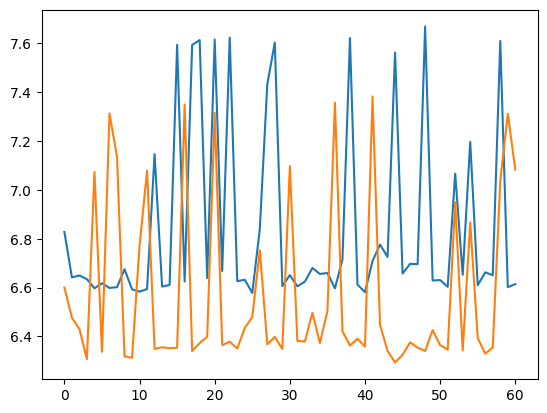

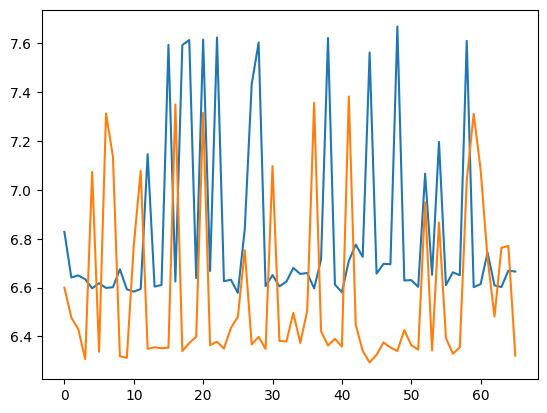

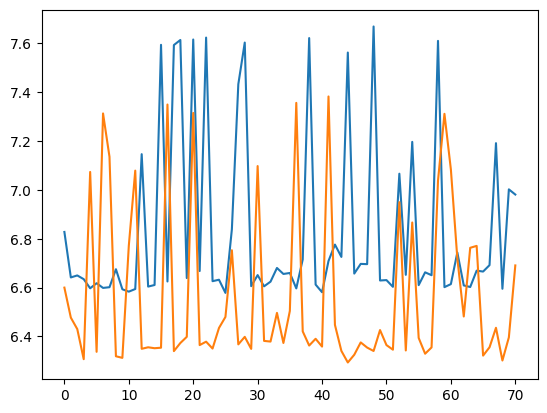

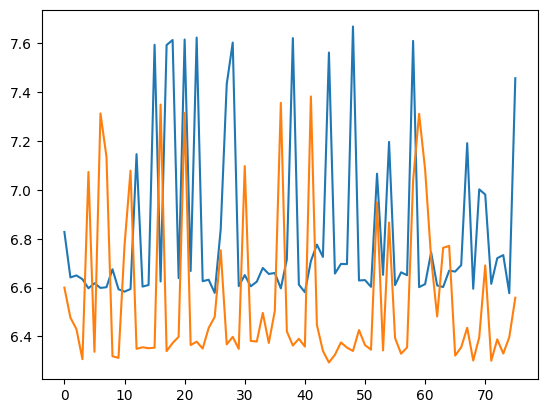

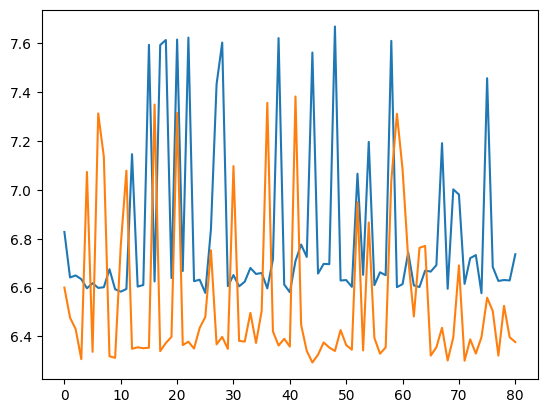

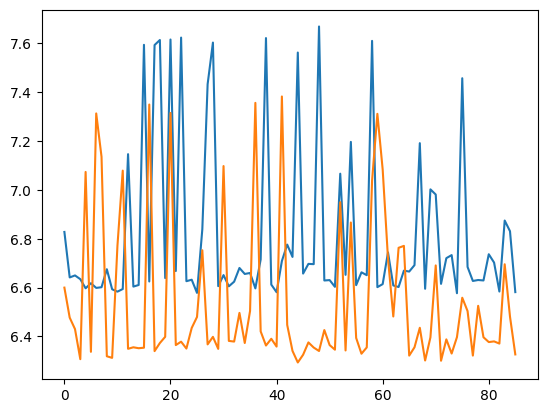

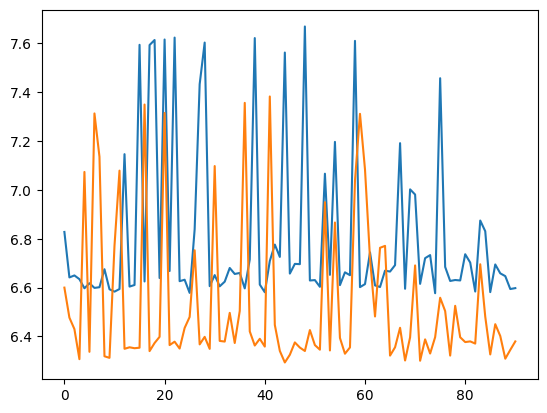

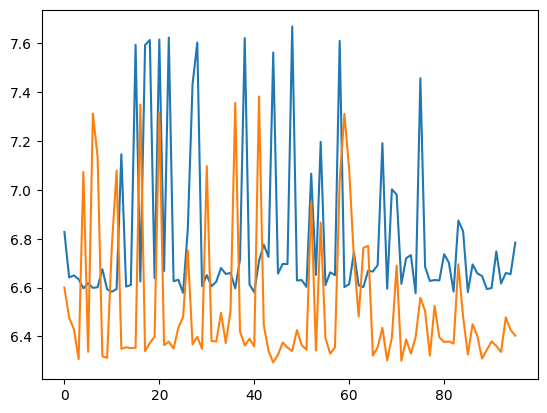

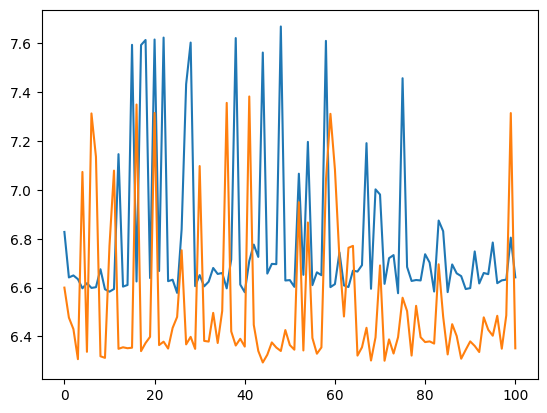

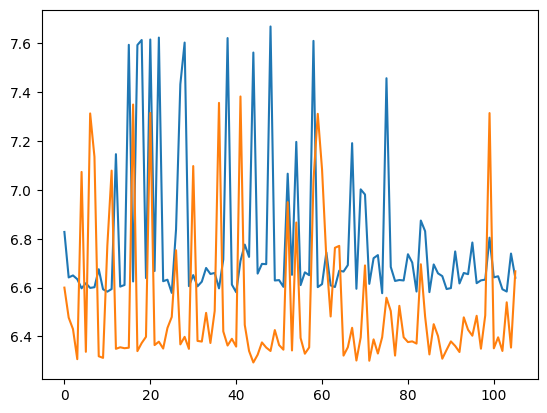

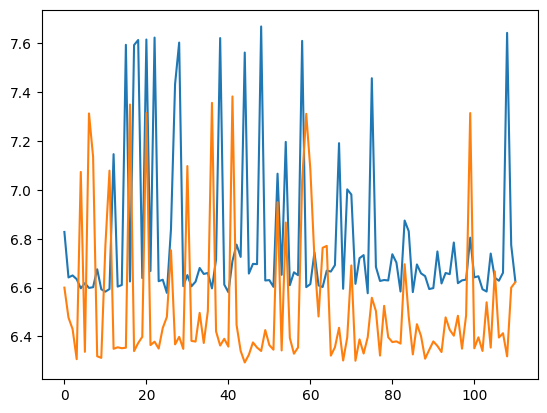

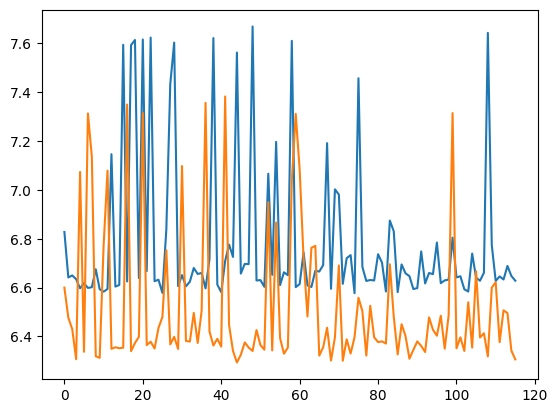

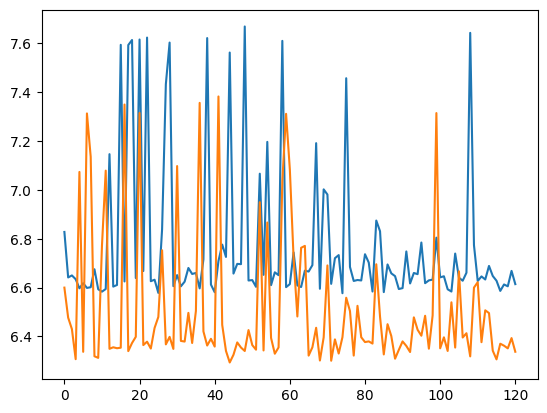

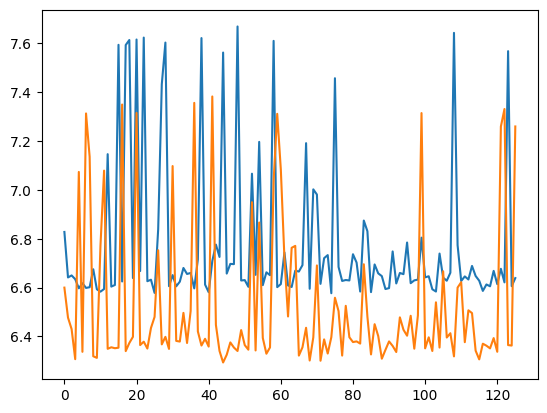

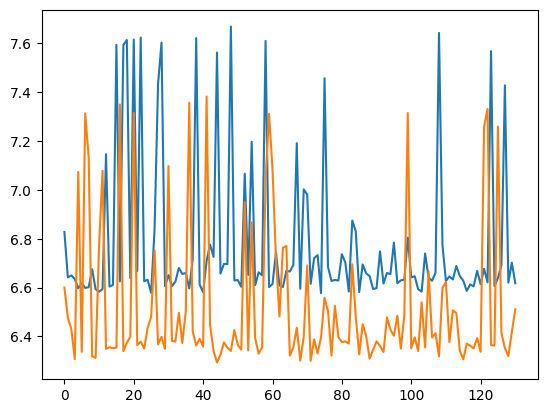

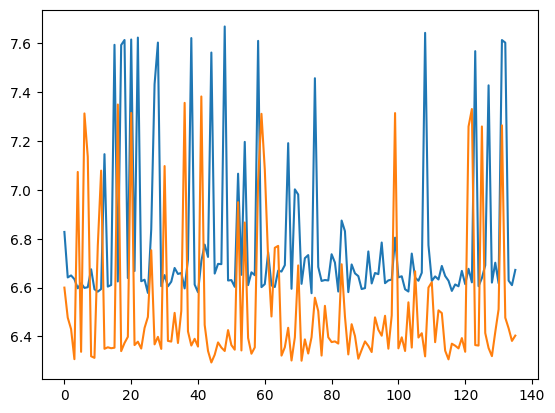

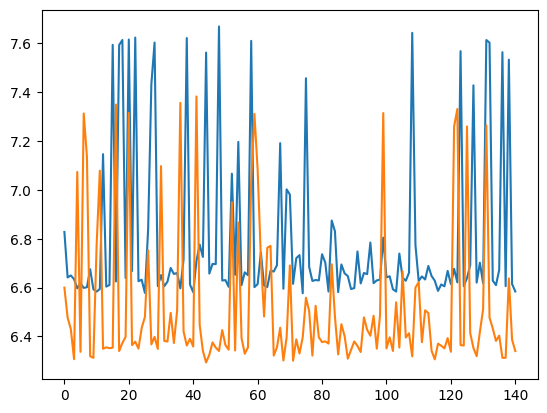

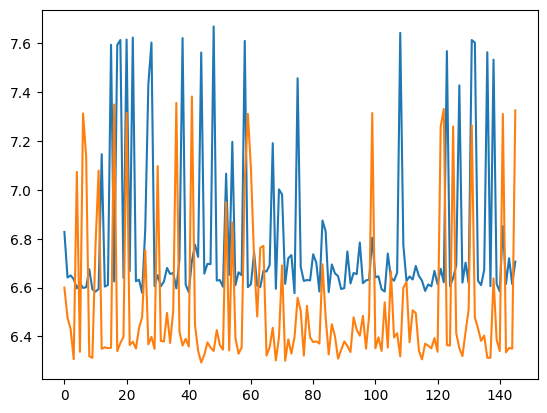

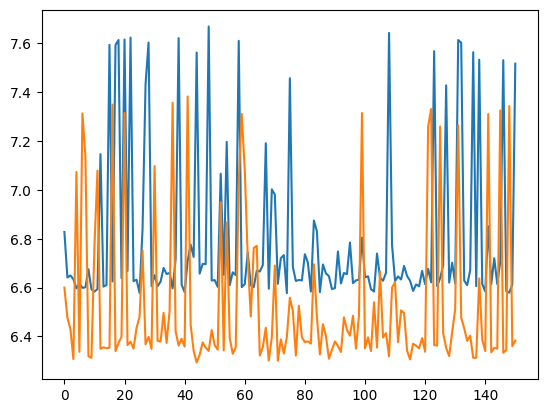

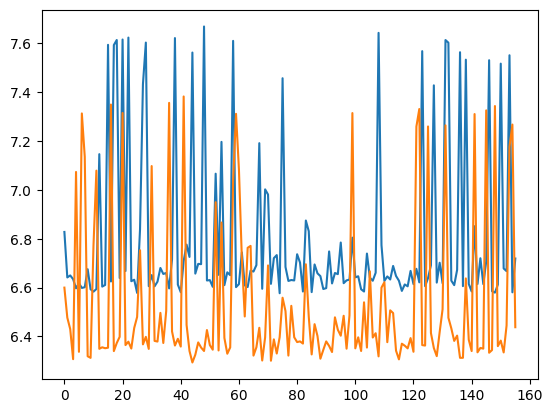

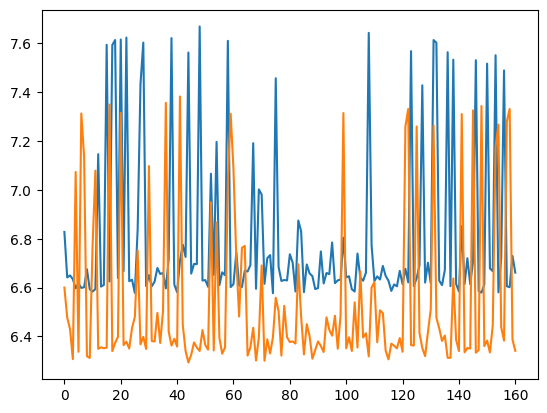

In [48]:
batch_size = 16

train_loss = []
val_loss = []

for i in tqdm(range(0, len(train), batch_size), total=len(train) // batch_size):
    if i + batch_size > len(train):
        break
    
    batch = train[i : i + batch_size]
    batch = torch.tensor(batch)
    val_batch = val[i : i + batch_size]
    val_batch = torch.tensor(val_batch)
    
    batch_labels = train_labels[i : i + batch_size]
    batch_labels = torch.tensor(batch_labels)
    val_batch_labels = val_labels[i : i + batch_size]
    val_batch_labels = torch.tensor(val_batch_labels)
    
    preds = model.forward(batch)
    preds = preds.squeeze(dim=2)
    val_preds = model.forward(val_batch)
    val_preds = val_preds.squeeze(dim=2)
    
    batch_train_loss = torch.nn.functional.cross_entropy(preds, batch_labels)
    train_loss.append(batch_train_loss.detach().numpy())
    batch_val_loss = torch.nn.functional.cross_entropy(val_preds, val_batch_labels)
    val_loss.append(batch_val_loss.detach().numpy())
    
    batch_train_loss.backward()
    opt.step()
    opt.zero_grad()
    
    if i % 10 == 0:
        fig, ax = plt.subplots()
        ax.plot(train_loss)
        ax.plot(val_loss)
        
    
    

In [139]:
# TODO: val loss
# TODO: plot learning curves
# TODO: predict with trained